# 3) Compare Water-Content Results (True vs Rho-Converted vs AD)

Map rows (4 columns: Day 1/190/294/365):
- Row 1: True water content
- Row 2: Water content converted from inverted resistivity
- Row 3: Water content from AD theta inversion

Bottom row:
- Regolith representative-point 365-day water-content comparison


Regolith representative point: x=112.50 m, z=-7.37 m
Selected days: [1, 190, 294, 365]


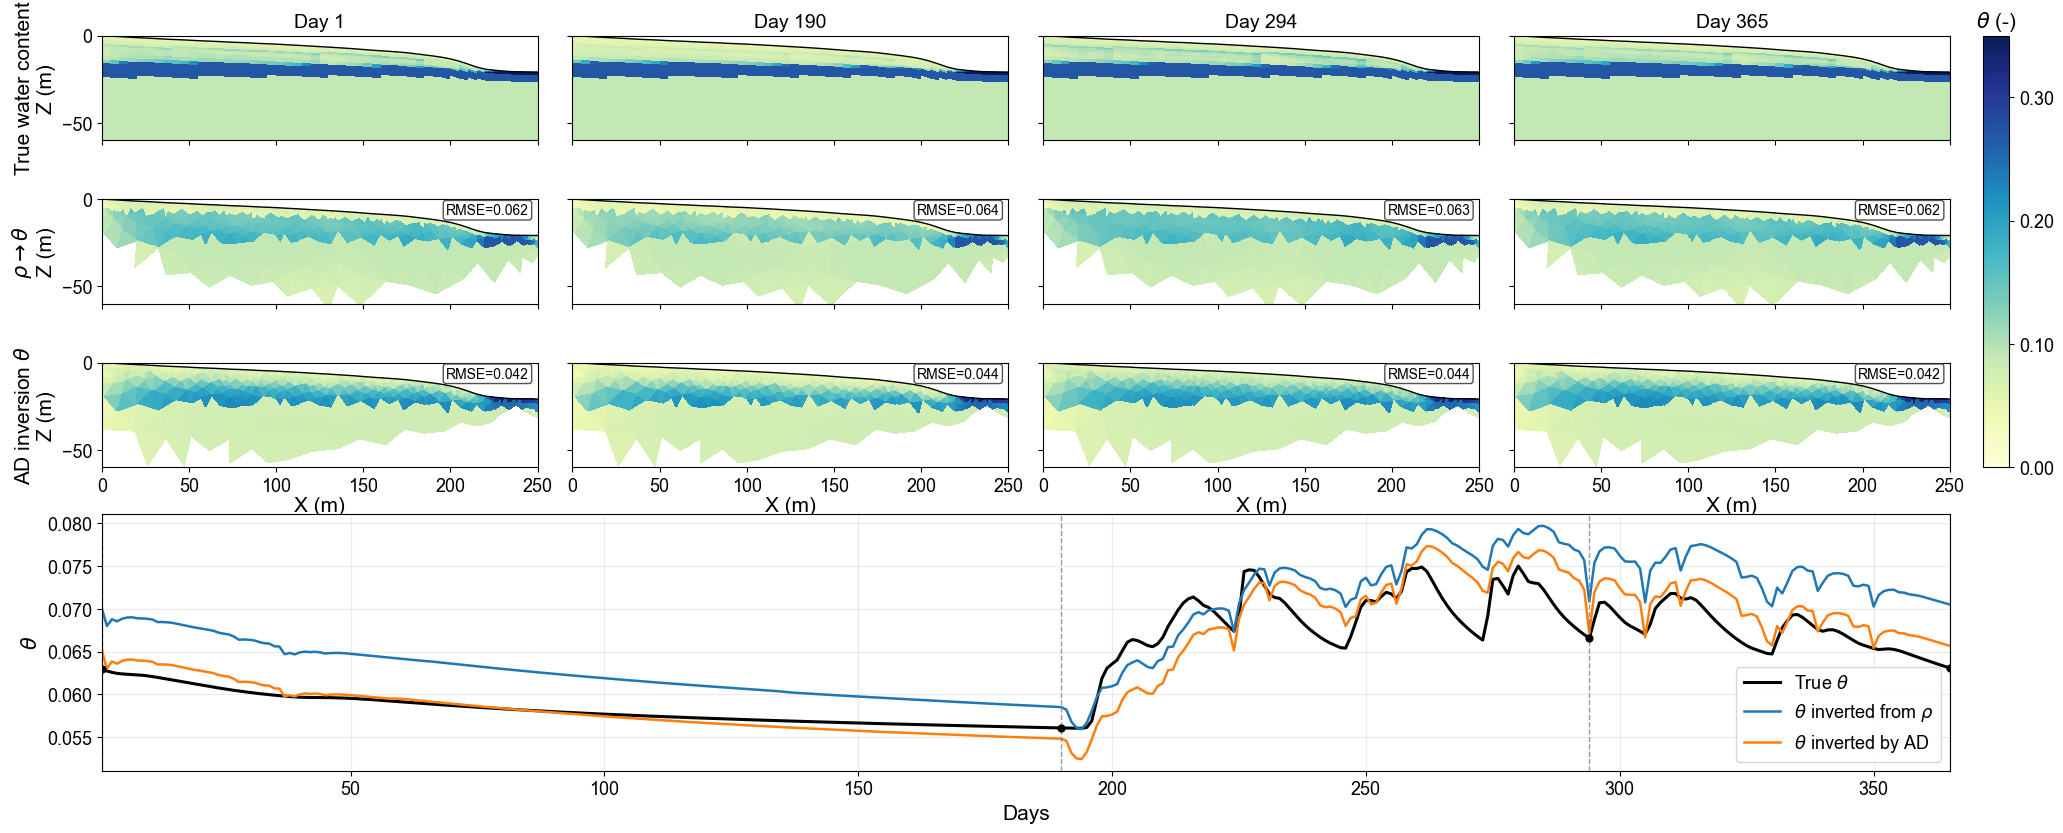

Saved: /home/luffy/deepertv1/result/7_physical_parameter/3_compare_physical_parameter.png


In [1]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import Normalize

from deepert.workflows.terrain import build_terrain_forward_case, parse_pftcl, read_slope_x

try:
    from parflow.tools.io import read_pfb
except Exception as exc:
    raise RuntimeError(
        "Failed to import parflow.tools.io.read_pfb. Run in project env: uv sync --extra examples"
    ) from exc

# ------------------------------------------------------------------
# A) Global setup
# ------------------------------------------------------------------
import logging
from matplotlib import font_manager

logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

arial_candidates = [
    Path("/mnt/c/Windows/Fonts/arial.ttf"),
    Path("/usr/share/fonts/truetype/msttcorefonts/Arial.ttf"),
    Path("/usr/share/fonts/truetype/msttcorefonts/arial.ttf"),
]
_use_arial = False
for _fp in arial_candidates:
    if _fp.exists():
        try:
            font_manager.fontManager.addfont(str(_fp))
            _use_arial = True
            break
        except Exception:
            pass

if _use_arial:
    plt.rcParams["font.family"] = "Arial"
    plt.rcParams["font.sans-serif"] = ["Arial", "DejaVu Sans"]
else:
    plt.rcParams["font.family"] = "DejaVu Sans"
    plt.rcParams["font.sans-serif"] = ["DejaVu Sans"]

selected_days = [1, 190, 294, 365]
selected_steps = [(d - 1) * 24 for d in selected_days]
y_index = 2

axis_label_fs = 15
tick_label_fs = 13
title_fs = 14
legend_fs = 13
metric_fs = 10

# ------------------------------------------------------------------
# B) Resolve paths
# ------------------------------------------------------------------
here = Path.cwd().resolve()
project_root = None
for candidate in [here, *here.parents]:
    if (candidate / "parflow_models").exists() and (candidate / "result").exists():
        project_root = candidate
        break
if project_root is None:
    raise FileNotFoundError(
        f"Cannot locate project root from cwd={here}. "
        "Expected a directory containing both 'parflow_models' and 'result'."
    )

parflow_dir = project_root / "parflow_models"
physical_root = project_root / "result" / "7_physical_parameter"
rho_case_dir = physical_root / "resistivity_then_convert"
ad_case_dir = physical_root / "ad_theta"

required = [
    rho_case_dir / "steps.npy",
    rho_case_dir / "timelapse_inversion_mesh.npz",
    rho_case_dir / "final_water_content_from_resistivity_models.npy",
    ad_case_dir / "steps.npy",
    ad_case_dir / "timelapse_inversion_mesh.npz",
]
for p in required:
    if not p.exists():
        raise FileNotFoundError(
            f"Missing required file: {p}\n"
            "Run: uv run python examples/7_physical_parameter/0_run_all_physical_parameter.py"
        )

# AD theta is produced directly by the water-content petrophysical transform.
ad_theta_path = ad_case_dir / "final_water_content_models.npy"
if not ad_theta_path.exists():
    raise FileNotFoundError(
        f"Missing direct AD theta output: {ad_theta_path}\n"
        "Run: uv run python examples/7_physical_parameter/2_timelapse_ad_theta.py"
    )

# ------------------------------------------------------------------
# C) Build physical terrain-following geometry
# ------------------------------------------------------------------
pftcl_path = parflow_dir / "sc2d_6.out.pftcl"
slope_x_path = parflow_dir / "sc2d_6.out.slope_x.pfb"
grid = parse_pftcl(pftcl_path)
slope_x = read_slope_x(slope_x_path, y_index=y_index)

rho_dummy = np.full((grid.nz, grid.nx), 100.0, dtype=float)
case_geom = build_terrain_forward_case(rho_dummy, grid, slope_x, y_index=y_index)

x_nodes = np.asarray(case_geom.x_nodes, dtype=float)
z_top = np.asarray(case_geom.z_top, dtype=float)
layer_thickness = np.asarray(case_geom.layer_thickness, dtype=float)

z_offsets = np.concatenate(([0.0], -np.cumsum(layer_thickness)))
Xn = np.tile(x_nodes[None, :], (grid.nz + 1, 1))
Zn = z_top[None, :] + z_offsets[:, None]
Xc = 0.25 * (Xn[:-1, :-1] + Xn[1:, :-1] + Xn[:-1, 1:] + Xn[1:, 1:])
Zc = 0.25 * (Zn[:-1, :-1] + Zn[1:, :-1] + Zn[:-1, 1:] + Zn[1:, 1:])
truth_xy = np.column_stack((Xc.ravel(), Zc.ravel()))

# ------------------------------------------------------------------
# D) True theta from ParFlow saturation * porosity
# ------------------------------------------------------------------
def _read_pfb_slice(path: Path, y_idx: int) -> np.ndarray:
    values_3d = np.asarray(read_pfb(str(path)), dtype=float)
    if values_3d.ndim != 3:
        raise ValueError(f"Expected 3D pfb at {path}, got shape {values_3d.shape}")
    if y_idx < 0 or y_idx >= values_3d.shape[1]:
        raise ValueError(f"y-index {y_idx} out of bounds for {path.name}")
    return np.asarray(values_3d[:, y_idx, :], dtype=float)


def _to_top_down(values_bottom_up: np.ndarray) -> np.ndarray:
    arr = np.asarray(values_bottom_up, dtype=float)
    if arr.shape != (grid.nz, grid.nx):
        raise ValueError(f"Expected {(grid.nz, grid.nx)}, got {arr.shape}")
    return arr[::-1, :]


porosity_bu = _read_pfb_slice(parflow_dir / "sc2d_6.out.porosity.pfb", y_index)
class_bu = np.asarray(_read_pfb_slice(parflow_dir / "class.pfb", y_index), dtype=int)
class_td = class_bu[::-1, :]

true_snapshots: dict[int, np.ndarray] = {}
for step in selected_steps:
    sat_bu = _read_pfb_slice(parflow_dir / f"sc2d_6.out.satur.{step:05d}.pfb", y_index)
    theta_bu = sat_bu * porosity_bu
    true_snapshots[step] = _to_top_down(theta_bu)

# representative regolith point
mask_regolith = class_td == 1
if not np.any(mask_regolith):
    raise ValueError("Class 1 (regolith) not found")
x_med = float(np.nanmedian(Xc[mask_regolith]))
z_med = float(np.nanmedian(Zc[mask_regolith]))
flat = np.flatnonzero(mask_regolith)
x_vals = Xc.ravel()[flat]
z_vals = Zc.ravel()[flat]
dist2 = (x_vals - x_med) ** 2 + (z_vals - z_med) ** 2
i_flat = int(flat[int(np.argmin(dist2))])
iz_rep, ix_rep = np.unravel_index(i_flat, class_td.shape)
x_rep = float(Xc[iz_rep, ix_rep])
z_rep = float(Zc[iz_rep, ix_rep])

n_days = 365
true_series = np.full(n_days, np.nan, dtype=float)
for d in range(1, n_days + 1):
    step = (d - 1) * 24
    sat_bu = _read_pfb_slice(parflow_dir / f"sc2d_6.out.satur.{step:05d}.pfb", y_index)
    theta_td = _to_top_down(sat_bu * porosity_bu)
    true_series[d - 1] = float(theta_td[iz_rep, ix_rep])

print(f"Regolith representative point: x={x_rep:.2f} m, z={z_rep:.2f} m")
print("Selected days:", selected_days)

# ------------------------------------------------------------------
# E) Load inverted theta from both cases
# ------------------------------------------------------------------
def _load_case_theta(case_dir: Path, theta_file: Path):
    steps = np.asarray(np.load(case_dir / "steps.npy"), dtype=int).ravel()
    theta = np.asarray(np.load(theta_file), dtype=float)
    with np.load(case_dir / "timelapse_inversion_mesh.npz") as mesh:
        nodes = np.asarray(mesh["nodes"], dtype=float)
        cells = np.asarray(mesh["cells"], dtype=np.int32)

    coverage_mask_path = case_dir / "coverage_mask.npy"
    if coverage_mask_path.exists():
        coverage_mask = np.asarray(np.load(coverage_mask_path), dtype=bool).ravel()
        if coverage_mask.size != theta.shape[0]:
            raise ValueError(
                f"{case_dir.name}: coverage_mask size {coverage_mask.size} != n_cells {theta.shape[0]}"
            )
    else:
        coverage_mask = np.zeros(theta.shape[0], dtype=bool)

    step_to_col = {int(s): i for i, s in enumerate(steps.tolist())}
    for step in selected_steps:
        if step not in step_to_col:
            raise KeyError(f"{case_dir.name}: selected step t={step:05d} not in steps.npy")

    snapshots = {step: theta[:, step_to_col[step]] for step in selected_steps}
    centers = nodes[cells].mean(axis=1)
    rep_idx = int(np.argmin((centers[:, 0] - x_rep) ** 2 + (centers[:, 1] - z_rep) ** 2))

    dist2_truth = (centers[:, [0]] - truth_xy[None, :, 0]) ** 2 + (centers[:, [1]] - truth_xy[None, :, 1]) ** 2
    truth_nn_idx = np.argmin(dist2_truth, axis=1)

    return {
        "steps": steps,
        "theta": theta,
        "nodes": nodes,
        "cells": cells,
        "coverage_mask": coverage_mask,
        "snapshots": snapshots,
        "rep_idx": rep_idx,
        "series": theta[rep_idx, :],
        "day_axis": (steps // 24) + 1,
        "truth_nn_idx": truth_nn_idx,
    }

rho_case = _load_case_theta(rho_case_dir, rho_case_dir / "final_water_content_from_resistivity_models.npy")
ad_case = _load_case_theta(ad_case_dir, ad_theta_path)

if rho_case["steps"].shape != ad_case["steps"].shape or np.any(rho_case["steps"] != ad_case["steps"]):
    raise ValueError("Step axis mismatch between resistivity-converted case and AD case.")

# ------------------------------------------------------------------
# F) Shared theta color scale
# ------------------------------------------------------------------
theta_vmin = 0.0
theta_vmax = 0.35
norm_theta = Normalize(vmin=theta_vmin, vmax=theta_vmax)

# ------------------------------------------------------------------
# G) Plot: 3x4 maps + 1x1 series
# ------------------------------------------------------------------
fig = plt.figure(figsize=(22, 8.3), constrained_layout=False)
gs = fig.add_gridspec(4, 4, height_ratios=[1.0, 1.0, 1.0, 2.0], hspace=0.22, wspace=0.08)

axes_maps = np.empty((3, 4), dtype=object)
for r in range(3):
    for c in range(4):
        axes_maps[r, c] = fig.add_subplot(gs[r, c])
ax_series = fig.add_subplot(gs[3, :])

row_labels = [
    "True water content",
    r"$\rho\rightarrow\theta$",
    r"AD inversion $\theta$",
]

last_mappable = None
for col, (day, step) in enumerate(zip(selected_days, selected_steps)):
    axes_maps[0, col].set_title(f"Day {day}", fontsize=title_fs)

    # Row 1: true theta on terrain-following structured grid
    ax0 = axes_maps[0, col]
    tm0 = ax0.pcolormesh(Xn, Zn, true_snapshots[step], shading="auto", cmap="YlGnBu", norm=norm_theta)
    tm0.set_clim(theta_vmin, theta_vmax)
    ax0.plot(x_nodes, z_top, "k-", lw=1.0)
    last_mappable = tm0

    # Row 2: theta converted from inverted resistivity
    ax1 = axes_maps[1, col]
    vals_rho = np.asarray(rho_case["snapshots"][step], dtype=float).copy()
    vals_rho[np.asarray(rho_case["coverage_mask"], dtype=bool)] = np.nan
    true_rho_mesh = np.asarray(true_snapshots[step], dtype=float).ravel()[np.asarray(rho_case["truth_nn_idx"], dtype=int)]
    valid_rho_rmse = np.isfinite(vals_rho) & np.isfinite(true_rho_mesh)
    rmse_rho = float(np.sqrt(np.mean((vals_rho[valid_rho_rmse] - true_rho_mesh[valid_rho_rmse]) ** 2))) if np.any(valid_rho_rmse) else np.nan
    tm1 = ax1.tripcolor(
        rho_case["nodes"][:, 0],
        rho_case["nodes"][:, 1],
        rho_case["cells"],
        vals_rho,
        shading="flat",
        cmap="YlGnBu",
        norm=norm_theta,
    )
    tm1.set_clim(theta_vmin, theta_vmax)
    ax1.plot(x_nodes, z_top, "k-", lw=1.0)
    ax1.text(
        0.98,
        0.96,
        f"RMSE={rmse_rho:.3f}",
        transform=ax1.transAxes,
        ha="right",
        va="top",
        fontsize=metric_fs,
        bbox=dict(facecolor="white", edgecolor="0.25", alpha=0.90, boxstyle="round,pad=0.20"),
        zorder=7,
    )
    last_mappable = tm1

    # Row 3: theta from direct AD theta inversion
    ax2 = axes_maps[2, col]
    vals_ad = np.asarray(ad_case["snapshots"][step], dtype=float).copy()
    vals_ad[np.asarray(ad_case["coverage_mask"], dtype=bool)] = np.nan
    true_ad_mesh = np.asarray(true_snapshots[step], dtype=float).ravel()[np.asarray(ad_case["truth_nn_idx"], dtype=int)]
    valid_ad_rmse = np.isfinite(vals_ad) & np.isfinite(true_ad_mesh)
    rmse_ad = float(np.sqrt(np.mean((vals_ad[valid_ad_rmse] - true_ad_mesh[valid_ad_rmse]) ** 2))) if np.any(valid_ad_rmse) else np.nan
    tm2 = ax2.tripcolor(
        ad_case["nodes"][:, 0],
        ad_case["nodes"][:, 1],
        ad_case["cells"],
        vals_ad,
        shading="flat",
        cmap="YlGnBu",
        norm=norm_theta,
    )
    tm2.set_clim(theta_vmin, theta_vmax)
    ax2.plot(x_nodes, z_top, "k-", lw=1.0)
    ax2.text(
        0.98,
        0.96,
        f"RMSE={rmse_ad:.3f}",
        transform=ax2.transAxes,
        ha="right",
        va="top",
        fontsize=metric_fs,
        bbox=dict(facecolor="white", edgecolor="0.25", alpha=0.90, boxstyle="round,pad=0.20"),
        zorder=7,
    )
    last_mappable = tm2

for r in range(3):
    for c in range(4):
        ax = axes_maps[r, c]
        ax.set_xlim(float(x_nodes.min()), float(x_nodes.max()))
        ax.set_ylim(-60.0, 0.0)
        ax.set_aspect("equal", adjustable="box")
        ax.tick_params(axis="both", labelsize=tick_label_fs)
        if r < 2:
            ax.tick_params(axis="x", labelbottom=False)
        else:
            ax.set_xlabel("X (m)", fontsize=axis_label_fs, labelpad=1)
        if c > 0:
            ax.tick_params(axis="y", labelleft=False)

for r in range(3):
    axes_maps[r, 0].set_ylabel(f"{row_labels[r]}\nZ (m)", fontsize=axis_label_fs)

# bottom row series
days = np.arange(1, n_days + 1, dtype=int)
ax_series.plot(days, true_series, color="black", lw=2.2, label=r"True $\theta$")
ax_series.plot(rho_case["day_axis"], rho_case["series"], lw=1.8, label=r"$\theta$ inverted from $\rho$")
ax_series.plot(ad_case["day_axis"], ad_case["series"], lw=1.8, label=r"$\theta$ inverted by AD")
for d in selected_days:
    ax_series.axvline(d, color="gray", ls="--", lw=1.0, alpha=0.8)
    ax_series.scatter([d], [true_series[d - 1]], color="black", s=24, zorder=6)

ax_series.set_xlim(1, n_days)
ax_series.grid(alpha=0.25)
ax_series.tick_params(axis="both", labelsize=tick_label_fs)
ax_series.set_xlabel("Days", fontsize=axis_label_fs)
ax_series.set_ylabel(r"$\theta$", fontsize=axis_label_fs)
ax_series.legend(loc="best", fontsize=legend_fs, frameon=True)

# colorbar only across first 3 rows
fig.subplots_adjust(left=0.06, right=0.90, top=0.96, bottom=0.06)
if last_mappable is not None:
    top_maps = axes_maps[0, 0].get_position().y1
    bottom_maps = axes_maps[2, 0].get_position().y0
    right_maps = axes_maps[0, 3].get_position().x1
    cax = fig.add_axes([right_maps + 0.015, bottom_maps, 0.012, top_maps - bottom_maps])
    cbar = fig.colorbar(last_mappable, cax=cax)
    theta_ticks = [0.0, 0.10, 0.20, 0.3]
    cbar.set_ticks(theta_ticks)
    cbar.set_ticklabels([f"{t:.2f}" for t in theta_ticks])
    cbar.ax.set_title(r"$\theta$ (-)", fontsize=axis_label_fs)
    cbar.ax.tick_params(labelsize=tick_label_fs)

out_png = physical_root / "3_compare_physical_parameter.png"
fig.savefig(out_png, dpi=600)
plt.show()

print("Saved:", out_png)
